<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Assignment_6_Fingerprint_Image_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 6: Fingerprint Image Segmentation
# README
This notebook runs semantic segmentation on fingerprint images using a U-Net model.
Steps will be:
- Load .npy dataset
- Split images and masks
- Build tf.data pipeline
- Train U-Net
- Visualize predictions


# 1. Environment Setup

In [1]:
!pip install tensorflow opencv-python matplotlib numpy

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
print('TensorFlow:', tf.__version__)

TensorFlow: 2.19.0


# 2. Upload Dataset

In [3]:
from google.colab import files
uploaded = files.upload()

Saving combined.npy to combined.npy
Saving fingerprint.jpg to fingerprint.jpg


In [4]:
data = np.load('combined.npy')
print('Shape:', data.shape)

Shape: (5000, 64, 84)


# 3. Split Images and Masks

In [5]:
images = data[:, :, :42]
masks = data[:, :, 42:]

print(images.shape, masks.shape)

(5000, 64, 42) (5000, 64, 42)


# 4. Visualization

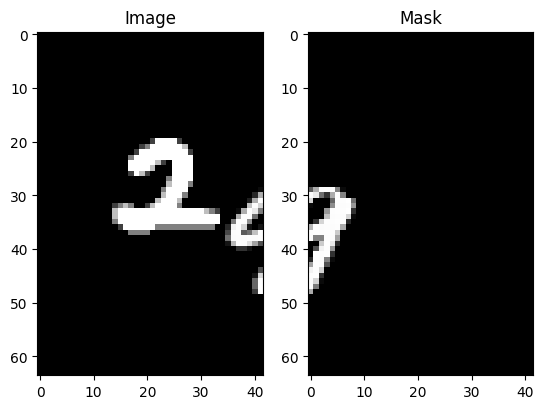

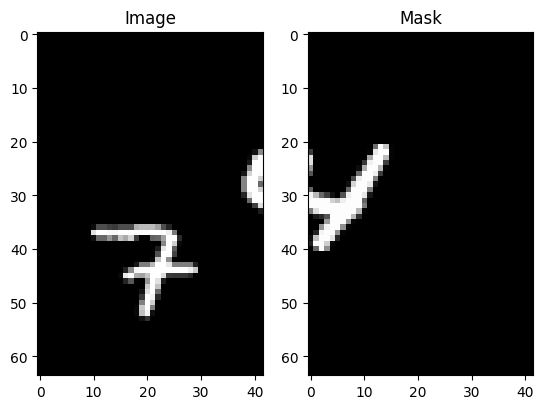

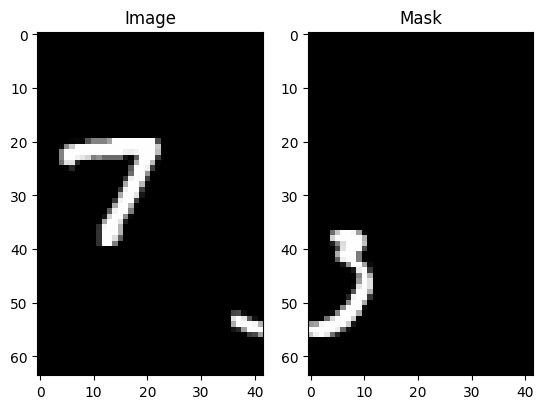

In [6]:
for i in range(3):
    plt.subplot(1,2,1)
    plt.imshow(images[i], cmap='gray')
    plt.title('Image')
    plt.subplot(1,2,2)
    plt.imshow(masks[i], cmap='gray')
    plt.title('Mask')
    plt.show()

# 5. Preprocessing

In [16]:
def preprocess(img, mask):
    # Add channel
    img = tf.expand_dims(img, -1)
    mask = tf.expand_dims(mask, -1)

    # Resize
    img = tf.image.resize(img, (256, 256))
    mask = tf.image.resize(mask, (256, 256), method='nearest')

    # Normalize image
    img = img / 255.0

    # Convert mask: 255 → 1
    mask = tf.where(mask > 0, 1, 0)

    # Convert type
    mask = tf.cast(mask, tf.int32)

    # Remove channel for loss
    mask = tf.squeeze(mask, axis=-1)

    return img, mask

In [17]:
dataset = tf.data.Dataset.from_tensor_slices((images, masks))

dataset = dataset.map(preprocess)\
                 .shuffle(100)\
                 .batch(4)\
                 .prefetch(tf.data.AUTOTUNE)

# 6. U-Net Model

In [18]:

def conv_block(x, filters):
    x = tf.keras.layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    return x

inputs = tf.keras.Input((256,256,1))

c1 = conv_block(inputs, 32)
p1 = tf.keras.layers.MaxPooling2D()(c1)

c2 = conv_block(p1, 64)
p2 = tf.keras.layers.MaxPooling2D()(c2)

c3 = conv_block(p2, 128)

u1 = tf.keras.layers.UpSampling2D()(c3)
u1 = tf.keras.layers.Concatenate()([u1, c2])
c4 = conv_block(u1, 64)

u2 = tf.keras.layers.UpSampling2D()(c4)
u2 = tf.keras.layers.Concatenate()([u2, c1])
c5 = conv_block(u2, 32)

outputs = tf.keras.layers.Conv2D(2, 1, activation='softmax')(c5)

model = tf.keras.Model(inputs, outputs)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 256, 256,  │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 256, 256,  │      9,248 │ conv2d_11[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 128, 128,  │          0 │ conv2d_12[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 128, 128,  │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_13[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ conv2d_14[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_3[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 64, 64,    │    147,584 │ conv2d_15[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 128, 128,  │          0 │ conv2d_16[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 128, 128,  │          0 │ up_sampling2d_2[… │
│ (Concatenate)       │ 192)              │            │ conv2d_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 128, 128,  │    110,656 │ concatenate_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_17[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 256, 256,  │          0 │ conv2d_18[0][0]   │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 256, 256,  │          0 │ up_sampling2d_3[… │
│ (Concatenate)       │ 96)               │            │ conv2d_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 256, 256,  │     27,680 │ concatenate_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │      9,248 │ conv2d_19[0][0] 

 Total params: 471,010 (1.80 MB)

 Trainable params: 471,010 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

# 7. Train Model

In [20]:
history = model.fit(dataset, epochs=1)

 135/1250 ━━━━━━━━━━━━━━━━━━━━ 1:38:33 5s/step - accuracy: 0.9525 - loss: 0.2552

KeyboardInterrupt: 

## 8. Predictions

In [ ]:

for img, mask in dataset.take(1):
    pred = model.predict(img)
    pred_mask = tf.argmax(pred, axis=-1)

    for i in range(3):
        plt.subplot(1,3,1)
        plt.imshow(img[i].numpy().squeeze(), cmap='gray')
        plt.title('Image')

        plt.subplot(1,3,2)
        plt.imshow(mask[i].numpy().squeeze(), cmap='gray')
        plt.title('True')

        plt.subplot(1,3,3)
        plt.imshow(pred_mask[i], cmap='gray')
        plt.title('Predicted')

        plt.show()